In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
folder_location = '/content/drive/MyDrive/Stat_Docs/BraTS-Africa'

In [4]:
import os
os.listdir(folder_location)

['95_Glioma', '51_OtherNeoplasms']

#EDA

In [5]:
!pip install nibabel pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 25.7 MB/s eta 0:00:00


In [29]:
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from collections import defaultdict
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

glioma_path = os.path.join(folder_location, '95_Glioma')
other_path = os.path.join(folder_location, '51_OtherNeoplasms')

# Explore folder structures
print(" Glioma Folder Structure")
for item in os.listdir(glioma_path)[:5]:  # Show first 5 items
    print(f"- {item}")
    subpath = os.path.join(glioma_path, item)
    if os.path.isdir(subpath):
        print(f"  Contains: {os.listdir(subpath)[:3]}")  # First 3 files

print("\n Other Neoplasms Folder Structure ")
for item in os.listdir(other_path)[:5]:
    print(f"- {item}")
    subpath = os.path.join(other_path, item)
    if os.path.isdir(subpath):
        print(f"  Contains: {os.listdir(subpath)[:3]}")

 Glioma Folder Structure
- BraTS-SSA-00121-000
  Contains: ['BraTS-SSA-00121-000-seg.nii.gz', 'BraTS-SSA-00121-000-t2f.nii.gz', 'BraTS-SSA-00121-000-t1c.nii.gz']
- BraTS-SSA-00206-000
  Contains: ['BraTS-SSA-00206-000-t1n.nii.gz', 'BraTS-SSA-00206-000-t2f.nii.gz', 'BraTS-SSA-00206-000-t1c.nii.gz']
- BraTS-SSA-00050-000
  Contains: ['BraTS-SSA-00050-000-seg.nii.gz', 'BraTS-SSA-00050-000-t2w.nii.gz', 'BraTS-SSA-00050-000-t2f.nii.gz']
- BraTS-SSA-00223-000
  Contains: ['BraTS-SSA-00223-000-seg.nii.gz', 'BraTS-SSA-00223-000-t1n.nii.gz', 'BraTS-SSA-00223-000-t2f.nii.gz']
- BraTS-SSA-00093-000
  Contains: ['BraTS-SSA-00093-000-t1c.nii.gz', 'BraTS-SSA-00093-000-t2f.nii.gz', 'BraTS-SSA-00093-000-t1n.nii.gz']

 Other Neoplasms Folder Structure 
- BraTS-SSA-00164-000
  Contains: ['BraTS-SSA-00164-000-seg.nii.gz', 'BraTS-SSA-00164-000-t2w.nii.gz', 'BraTS-SSA-00164-000-t2f.nii.gz']
- BraTS-SSA-00166-000
  Contains: ['BraTS-SSA-00166-000-t1n.nii.gz', 'BraTS-SSA-00166-000-t2f.nii.gz', 'BraTS-SSA-001

Dataset Summary 
Glioma patients/cases: 95
Other Neoplasms patients/cases: 51
Total: 146


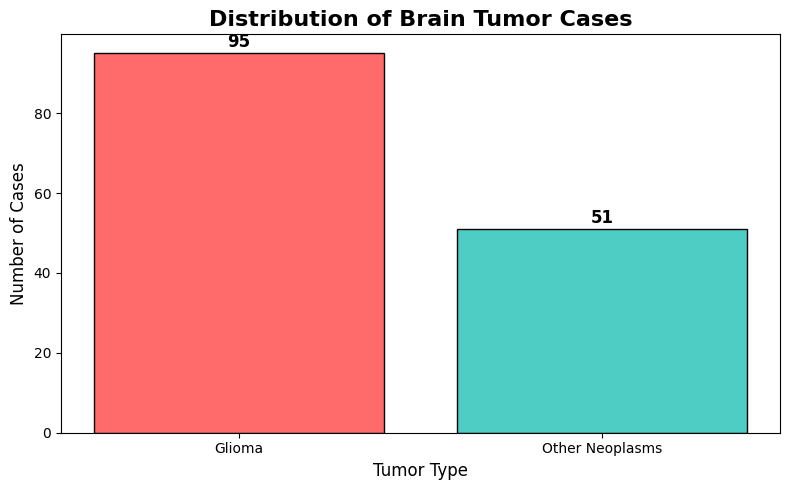

In [7]:
# Count patients/scans per tumor type
glioma_patients = [d for d in os.listdir(glioma_path) if os.path.isdir(os.path.join(glioma_path, d))]
other_patients = [d for d in os.listdir(other_path) if os.path.isdir(os.path.join(other_path, d))]

print("Dataset Summary ")
print(f"Glioma patients/cases: {len(glioma_patients)}")
print(f"Other Neoplasms patients/cases: {len(other_patients)}")
print(f"Total: {len(glioma_patients) + len(other_patients)}")

# Create a simple visualization
plt.figure(figsize=(8, 5))
categories = ['Glioma', 'Other Neoplasms']
counts = [len(glioma_patients), len(other_patients)]
colors = ['#FF6B6B', '#4ECDC4']
bars = plt.bar(categories, counts, color=colors, edgecolor='black')
plt.title('Distribution of Brain Tumor Cases', fontsize=16, fontweight='bold')
plt.ylabel('Number of Cases', fontsize=12)
plt.xlabel('Tumor Type', fontsize=12)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

In [8]:
def load_sample_nifti(tumor_type='Glioma'):
    """
    Load a sample NIfTI file from the dataset
    """
    if tumor_type == 'Glioma':
        base_path = glioma_path
    else:
        base_path = other_path

    # Get first patient folder
    patients = [d for d in os.listdir(base_path) if os.path.isdir(os.path.join(base_path, d))]
    if not patients:
        print(f"No patients found in {tumor_type} folder")
        return None

    patient_folder = os.path.join(base_path, patients[0])

    # Look for NIfTI files (.nii or .nii.gz)
    nifti_files = []
    for root, dirs, files in os.walk(patient_folder):
        for file in files:
            if file.endswith('.nii') or file.endswith('.nii.gz'):
                nifti_files.append(os.path.join(root, file))

    if not nifti_files:
        print(f"No NIfTI files found in {patient_folder}")
        return None

    print(f"Loading sample from {tumor_type} - Patient: {patients[0]}")
    print(f"Found {len(nifti_files)} NIfTI file(s)")

    # Load first NIfTI file
    img = nib.load(nifti_files[0])
    data = img.get_fdata()

    return data, img, nifti_files[0]

# Test loading from Glioma
glioma_data, glioma_img, glioma_file = load_sample_nifti('Glioma')
if glioma_data is not None:
    print(f"\nImage shape: {glioma_data.shape}")
    print(f"Data type: {glioma_data.dtype}")
    print(f"Pixel value range: {glioma_data.min():.2f} - {glioma_data.max():.2f}")

# test loading from other neoplasms
other_data, other_img, other_file = load_sample_nifti('Other Neoplasms')
if other_data is not None:
    print(f"\nImage shape: {other_data.shape}")
    print(f"Data type: {other_data.dtype}")
    print(f"Pixel value range: {other_data.min():.2f} - {other_data.max():.2f}")

Loading sample from Glioma - Patient: BraTS-SSA-00121-000
Found 5 NIfTI file(s)

Image shape: (240, 240, 155)
Data type: float64
Pixel value range: 0.00 - 3.00
Loading sample from Other Neoplasms - Patient: BraTS-SSA-00164-000
Found 5 NIfTI file(s)

Image shape: (240, 240, 155)
Data type: float64
Pixel value range: 0.00 - 3.00


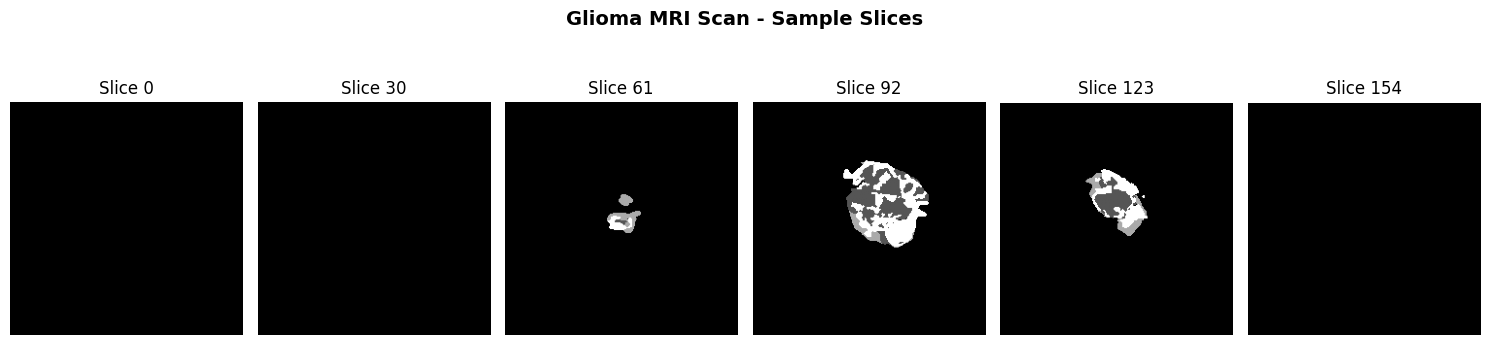

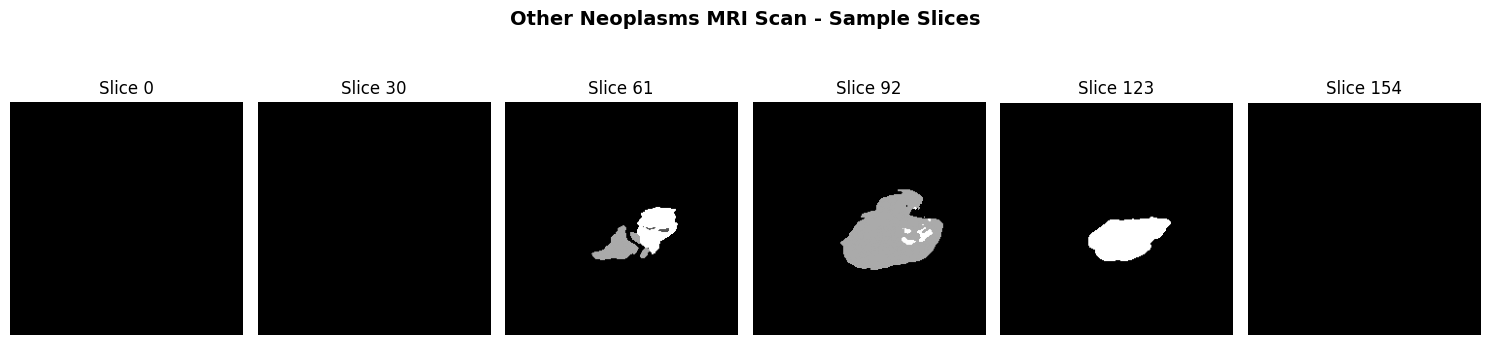

In [9]:
def visualize_mri_slices(data, title="MRI Scan", num_slices=6):
    """
    Display multiple slices from a 3D MRI volume
    """
    if data is None:
        print("No data to visualize")
        return

    # Get dimensions
    depth = data.shape[2] if len(data.shape) > 2 else 1

    # Select evenly spaced slices
    if depth > num_slices:
        slice_indices = np.linspace(0, depth-1, num_slices, dtype=int)
    else:
        slice_indices = range(depth)
        num_slices = depth

    fig, axes = plt.subplots(1, num_slices, figsize=(15, 4))
    if num_slices == 1:
        axes = [axes]

    for i, idx in enumerate(slice_indices):
        if len(data.shape) == 3:
            slice_data = data[:, :, idx]
        else:
            slice_data = data

        im = axes[i].imshow(slice_data, cmap='gray')
        axes[i].set_title(f'Slice {idx}')
        axes[i].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize the sample Glioma and Other Neoplasms scan
if glioma_data is not None:
    visualize_mri_slices(glioma_data, title="Glioma MRI Scan - Sample Slices")
if other_data is not None:
    visualize_mri_slices(other_data, title="Other Neoplasms MRI Scan - Sample Slices")


 Glioma - Intensity Statistics 
Total pixels: 8,928,000
Non-zero pixels: 255,630 (2.86%)
Mean intensity: 2.06
Median intensity: 2.00
Std deviation: 0.94
Min intensity: 1.00
Max intensity: 3.00


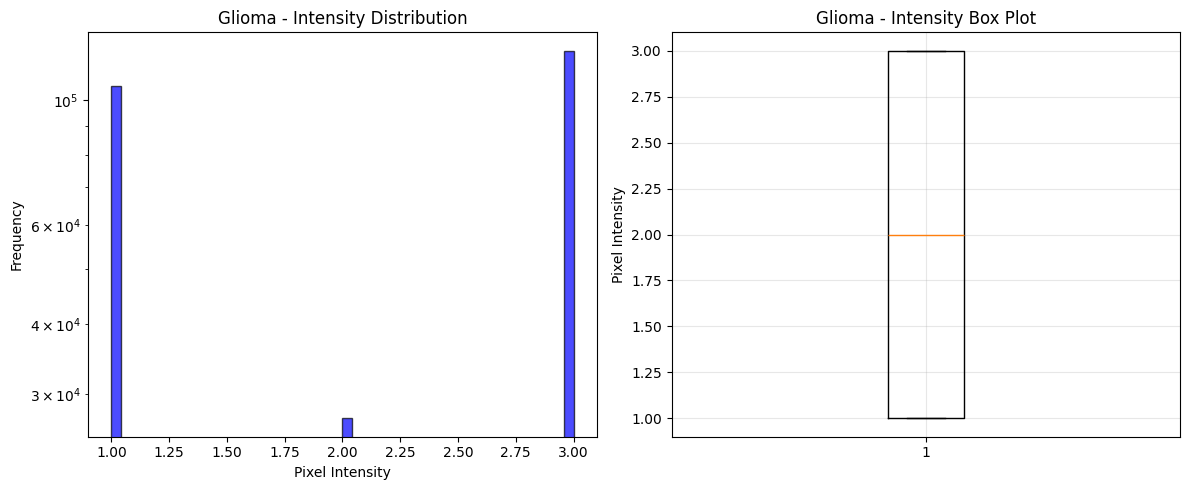

Loading sample from Other Neoplasms - Patient: BraTS-SSA-00164-000
Found 5 NIfTI file(s)

 Other Neoplasms - Intensity Statistics 
Total pixels: 8,928,000
Non-zero pixels: 308,038 (3.45%)
Mean intensity: 2.17
Median intensity: 2.00
Std deviation: 0.39
Min intensity: 1.00
Max intensity: 3.00


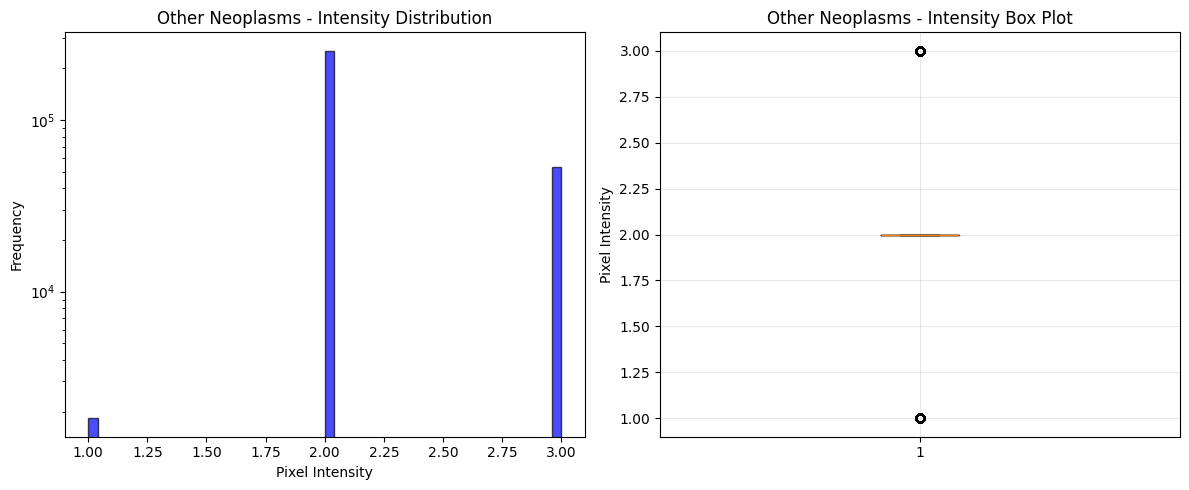

In [10]:
def analyze_intensity_distribution(data, tumor_type):
    """
    Analyze pixel intensity statistics
    """
    if data is None:
        return

    # Flatten the array
    flat_data = data.flatten()

    # Remove zeros (background) for better analysis
    non_zero = flat_data[flat_data > 0]

    print(f"\n {tumor_type} - Intensity Statistics ")
    print(f"Total pixels: {len(flat_data):,}")
    print(f"Non-zero pixels: {len(non_zero):,} ({len(non_zero)/len(flat_data)*100:.2f}%)")
    print(f"Mean intensity: {np.mean(non_zero):.2f}")
    print(f"Median intensity: {np.median(non_zero):.2f}")
    print(f"Std deviation: {np.std(non_zero):.2f}")
    print(f"Min intensity: {np.min(non_zero):.2f}")
    print(f"Max intensity: {np.max(non_zero):.2f}")

    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Histogram
    axes[0].hist(non_zero, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[0].set_title(f'{tumor_type} - Intensity Distribution')
    axes[0].set_xlabel('Pixel Intensity')
    axes[0].set_ylabel('Frequency')
    axes[0].set_yscale('log')

    # Box plot
    axes[1].boxplot(non_zero, vert=True)
    axes[1].set_title(f'{tumor_type} - Intensity Box Plot')
    axes[1].set_ylabel('Pixel Intensity')
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Analyze both tumor types
if glioma_data is not None:
    analyze_intensity_distribution(glioma_data, "Glioma")

# Load and analyze Other Neoplasms sample
other_data, other_img, other_file = load_sample_nifti('Other Neoplasms')
if other_data is not None:
    analyze_intensity_distribution(other_data, "Other Neoplasms")

In [11]:

def analyze_segmentation_mask(nifti_path):
    """Check if segmentation masks exist and their label distribution"""
    import nibabel as nib
    import numpy as np
    import matplotlib.pyplot as plt

    img = nib.load(nifti_path)
    mask = img.get_fdata()

    print(f"Mask shape: {mask.shape}")
    print(f"Unique labels: {np.unique(mask)}")

    # BraTS standard labels: 1=necrosis, 2=edema, 3=non-enhancing, 4=enhancing
    for label in [1, 2, 3, 4]:
        if label in mask:
            voxel_count = np.sum(mask == label)
            print(f"  Label {label}: {voxel_count} voxels ({voxel_count/mask.size*100:.2f}%)")

    # Visualize mask overlay
    plt.figure(figsize=(12, 4))
    mid_slice = mask.shape[2] // 2
    plt.imshow(mask[:, :, mid_slice], cmap='tab10')
    plt.title(f"Segmentation Mask - Slice {mid_slice}")
    plt.colorbar()
    plt.show()

In [12]:
def get_nifti_metadata(nifti_path):
    """Extract physical spacing and orientation info"""
    import nibabel as nib

    img = nib.load(nifti_path)
    header = img.header

    print(f"Voxel spacing (mm): {header.get_zooms()}")
    print(f"Data shape: {header.get_data_shape()}")
    print(f"Data type: {header.get_data_dtype()}")

    # Affine matrix shows orientation
    affine = img.affine
    print(f"Orientation (RAS/LAS/etc.): {nib.aff2axcodes(affine)}")

    return header.get_zooms()

In [13]:

# Apply to samples
if glioma_file:
    spacing = get_nifti_metadata(glioma_file)
if other_file:
    spacing = get_nifti_metadata(other_file)


Voxel spacing (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data shape: (240, 240, 155)
Data type: float32
Orientation (RAS/LAS/etc.): ('R', 'A', 'S')
Voxel spacing (mm): (np.float32(1.0), np.float32(1.0), np.float32(1.0))
Data shape: (240, 240, 155)
Data type: float32
Orientation (RAS/LAS/etc.): ('R', 'A', 'S')


In [14]:
from sklearn.model_selection import train_test_split

# Get all patient IDs with their labels
all_patients = []
all_labels = []

for patient in glioma_patients:
    all_patients.append(patient)
    all_labels.append('Glioma')

for patient in other_patients:
    all_patients.append(patient)
    all_labels.append('Other')

# Stratified split
train_patients, temp_patients, train_labels, temp_labels = train_test_split(
    all_patients, all_labels, test_size=0.3, stratify=all_labels, random_state=42
)

val_patients, test_patients, val_labels, test_labels = train_test_split(
    temp_patients, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"\nDataset Split")
print(f"Train: {len(train_patients)} patients")
print(f"Validation: {len(val_patients)} patients")
print(f"Test: {len(test_patients)} patients")



Dataset Split
Train: 102 patients
Validation: 22 patients
Test: 22 patients


In [15]:
def identify_sequences(patient_folder):
    """Identify which MRI sequences are present"""
    sequences = {'T1': None, 'T1c': None, 'T2': None, 'FLAIR': None, 'SEG': None}

    for file in os.listdir(patient_folder):
        file_lower = file.lower()
        if 't1' in file_lower and 'ce' not in file_lower:
            sequences['T1'] = file
        elif 't1ce' in file_lower or 't1gd' in file_lower:
            sequences['T1c'] = file
        elif 't2' in file_lower and 'flair' not in file_lower:
            sequences['T2'] = file
        elif 'flair' in file_lower:
            sequences['FLAIR'] = file
        elif 'seg' in file_lower:
            sequences['SEG'] = file

    return sequences

In [16]:

# Check glioma patient
first_glioma_folder = os.path.join(glioma_path, glioma_patients[0])
sequences = identify_sequences(first_glioma_folder)
print(f"\nSequences for {glioma_patients[0]} ")
for seq, filename in sequences.items():
    status = "available" if filename else "not available"
    print(f"{status} {seq}: {filename if filename else 'Not found'}")


# check for other neoplasms
first_other_folder = os.path.join(other_path, other_patients[0])
sequences = identify_sequences(first_other_folder)
print(f"\nSequences for {other_patients[0]} ")
for seq, filename in sequences.items():
    status = "available" if filename else "not available"
    print(f"{status} {seq}: {filename if filename else 'Not found'}")


Sequences for BraTS-SSA-00121-000 
available T1: BraTS-SSA-00121-000-t1n.nii.gz
not available T1c: Not found
available T2: BraTS-SSA-00121-000-t2w.nii.gz
not available FLAIR: Not found
available SEG: BraTS-SSA-00121-000-seg.nii.gz

Sequences for BraTS-SSA-00164-000 
available T1: BraTS-SSA-00164-000-t1c.nii.gz
not available T1c: Not found
available T2: BraTS-SSA-00164-000-t2f.nii.gz
not available FLAIR: Not found
available SEG: BraTS-SSA-00164-000-seg.nii.gz


In [17]:
def complete_preprocess(nifti_path, target_shape=(128, 128, 128)):
    """
    Full preprocessing pipeline:
    - Load and normalize
    - Resample to isotropic spacing
    - Resize to target shape
    - Extract patches for 3D CNN
    """
    from scipy.ndimage import zoom

    img = nib.load(nifti_path)
    data = img.get_fdata()

    # Normalize
    nonzero = data[data > 0]
    if len(nonzero) > 0:
        data = (data - nonzero.mean()) / (nonzero.std() + 1e-8)

    # Resize to target shape
    current_shape = data.shape
    zoom_factors = [t / c for t, c in zip(target_shape, current_shape)]
    resized = zoom(data, zoom_factors, order=1)

    return resized

In [18]:

# Test
if glioma_file:
    preprocessed = complete_preprocess(glioma_file)
    print(f"\nPreprocessed shape: {preprocessed.shape}")
    print(f"Preprocessed range: {preprocessed.min():.2f} - {preprocessed.max():.2f}")
if other_file:
  preprocessed = complete_preprocess(other_file)
  print(f"\nPreprocessed shape: {preprocessed.shape}")
  print(f"Preprocessed range: {preprocessed.min():.2f} - {preprocessed.max():.2f}")



Preprocessed shape: (128, 128, 128)
Preprocessed range: -2.19 - 0.99

Preprocessed shape: (128, 128, 128)
Preprocessed range: -5.58 - 2.14


In [19]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array(all_labels)
unique_classes = np.unique(classes)
weights = compute_class_weight('balanced', classes=unique_classes, y=classes)
class_weight_dict = dict(zip(unique_classes, weights))

print(f"\n Class Weights (for loss function)")
for tumor_type, weight in class_weight_dict.items():
    print(f"{tumor_type}: {weight:.3f}")


 Class Weights (for loss function)
Glioma: 0.768
Other: 1.431


In [22]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


In [24]:

# Find patients with segmentation masks
segmentation_patients = []

for path, tumor_type in [(glioma_path, 'Glioma'), (other_path, 'Other')]:
    patients_in_folder = [d for d in os.listdir(path) if os.path.isdir(os.path.join(path, d))]

    for patient_id in patients_in_folder:
        patient_folder = os.path.join(path, patient_id)
        files = os.listdir(patient_folder)

        current_patient_sequences = {'t1': None, 't1ce': None, 't2': None, 'flair': None, 'seg': None}

        for file in files:
            file_lower = file.lower()
            if 'seg' in file_lower:
                current_patient_sequences['seg'] = file
            # T1 Contrast-enhanced (t1c, t1ce, t1gd)
            elif 't1ce' in file_lower or 't1gd' in file_lower or ('t1' in file_lower and 'c' in file_lower and 'w' not in file_lower and 'n' not in file_lower):
                current_patient_sequences['t1ce'] = file
            # FLAIR (flair, t2f)
            elif 'flair' in file_lower or 't2f' in file_lower:
                current_patient_sequences['flair'] = file
            # T2-weighted (t2, t2w) - exclude flair-like
            elif 't2' in file_lower and 'flair' not in file_lower and 'f' not in file_lower:
                current_patient_sequences['t2'] = file
            # T1-weighted native (t1, t1n, t1w) - exclude contrast-enhanced
            elif 't1' in file_lower and 'ce' not in file_lower and 'gd' not in file_lower and 'c' not in file_lower:
                current_patient_sequences['t1'] = file


        # Ensure a segmentation file is present and at least one MRI sequence
        if current_patient_sequences['seg']:
            has_mri_sequence = any([current_patient_sequences['t1'],
                                    current_patient_sequences['t1ce'],
                                    current_patient_sequences['t2'],
                                    current_patient_sequences['flair']])
            if has_mri_sequence:
                segmentation_patients.append({
                    'patient_id': patient_id,
                    'tumor_type': tumor_type,
                    'folder': patient_folder,
                    't1': current_patient_sequences['t1'],
                    't2': current_patient_sequences['t2'],
                    't1ce': current_patient_sequences['t1ce'],
                    'flair': current_patient_sequences['flair'],
                    'seg': current_patient_sequences['seg']
                })
            else:
                print(f"Warning: Patient {patient_id} has a segmentation mask but no MRI sequences found. Skipping.")

print(f"Found {len(segmentation_patients)} patients with segmentation masks and at least one MRI sequence.")
print(f"Glioma: {sum(1 for p in segmentation_patients if p['tumor_type'] == 'Glioma')}")
print(f"Other Neoplasms: {sum(1 for p in segmentation_patients if p['tumor_type'] == 'Other')}")

Found 146 patients with segmentation masks
Glioma: 95
Other Neoplasms: 51


In [25]:
class BratsSegmentationDataset(Dataset):
    def __init__(self, patients, target_size=(128, 128, 128)):
        self.patients = patients
        self.target_size = target_size

    def __len__(self):
        return len(self.patients)

    def load_and_preprocess(self, file_path):
        """Load NIfTI and normalize"""
        img = nib.load(file_path)
        data = img.get_fdata().astype(np.float32)

        # Normalize
        nonzero = data[data > 0]
        if len(nonzero) > 0:
            data = (data - nonzero.mean()) / (nonzero.std() + 1e-8)

        return data

    def resize_volume(self, volume, target_shape):
        """Resize 3D volume to target shape"""
        from scipy.ndimage import zoom
        current_shape = volume.shape
        zoom_factors = [target_shape[i] / current_shape[i] for i in range(3)]
        return zoom(volume, zoom_factors, order=1)

    def __getitem__(self, idx):
        patient = self.patients[idx]

        # Load all available sequences
        sequences = []
        seq_names = []

        if patient['t1']:
            seq_data = self.load_and_preprocess(os.path.join(patient['folder'], patient['t1']))
            sequences.append(seq_data)
            seq_names.append('t1')

        if patient['t2']:
            seq_data = self.load_and_preprocess(os.path.join(patient['folder'], patient['t2']))
            sequences.append(seq_data)
            seq_names.append('t2')

        if patient['t1ce']:
            seq_data = self.load_and_preprocess(os.path.join(patient['folder'], patient['t1ce']))
            sequences.append(seq_data)
            seq_names.append('t1ce')

        if patient['flair']:
            seq_data = self.load_and_preprocess(os.path.join(patient['folder'], patient['flair']))
            sequences.append(seq_data)
            seq_names.append('flair')

        # Stack sequences as channels
        if len(sequences) > 1:
            image = np.stack(sequences, axis=-1)
        else:
            image = sequences[0][..., np.newaxis]

        # Load segmentation mask
        seg = self.load_and_preprocess(os.path.join(patient['folder'], patient['seg']))

        # Resize to target size
        image_resized = np.zeros((*self.target_size, image.shape[-1]))
        for c in range(image.shape[-1]):
            image_resized[..., c] = self.resize_volume(image[..., c], self.target_size)

        seg_resized = self.resize_volume(seg, self.target_size)

        # Convert to tensors [C, D, H, W] for image, [D, H, W] for seg
        image_tensor = torch.FloatTensor(image_resized).permute(3, 0, 1, 2)
        seg_tensor = torch.LongTensor(seg_resized).round().long()

        return image_tensor, seg_tensor

In [26]:



class AttentionBlock(nn.Module):
    """Attention Gate for U-Net"""
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv3d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm3d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv3d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm3d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv3d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm3d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class DoubleConv(nn.Module):
    """Double Convolution Block"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class AttentionUNet3D(nn.Module):
    """3D Attention U-Net for Brain Tumor Segmentation"""
    def __init__(self, in_channels=4, out_channels=4):  # 4 classes: 0=BG, 1=necrosis, 2=edema, 3=enhancing
        super(AttentionUNet3D, self).__init__()

        # Encoder
        self.enc1 = DoubleConv(in_channels, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.enc4 = DoubleConv(128, 256)

        # Pooling
        self.pool = nn.MaxPool3d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(256, 512)

        # Decoder with Attention Gates
        self.up4 = nn.ConvTranspose3d(512, 256, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=256, F_l=256, F_int=128)
        self.dec4 = DoubleConv(512, 256)

        self.up3 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=128, F_l=128, F_int=64)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=64, F_l=64, F_int=32)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=32, F_l=32, F_int=16)
        self.dec1 = DoubleConv(64, 32)

        # Output layer
        self.out_conv = nn.Conv3d(32, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck
        b = self.bottleneck(self.pool(e4))

        # Decoder with attention
        d4 = self.up4(b)
        e4_att = self.att4(g=d4, x=e4)
        d4 = torch.cat([e4_att, d4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        e3_att = self.att3(g=d3, x=e3)
        d3 = torch.cat([e3_att, d3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        e2_att = self.att2(g=d2, x=e2)
        d2 = torch.cat([e2_att, d2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        e1_att = self.att1(g=d1, x=e1)
        d1 = torch.cat([e1_att, d1], dim=1)
        d1 = self.dec1(d1)

        # Output
        out = self.out_conv(d1)
        return out


In [28]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, pred, target):
        pred = torch.softmax(pred, dim=1)
        target_one_hot = torch.nn.functional.one_hot(target, num_classes=4).permute(0, 4, 1, 2, 3).float()

        dice = 0
        for c in range(1, 4):  # Skip background
            pred_c = pred[:, c]
            target_c = target_one_hot[:, c]
            intersection = (pred_c * target_c).sum()
            union = pred_c.sum() + target_c.sum()
            dice += (2. * intersection + self.smooth) / (union + self.smooth)

        return 1 - dice / 3  # Average over 3 classes

In [30]:
# Split patients with masks
train_patients, val_patients = train_test_split(
    segmentation_patients, test_size=0.2, random_state=42, stratify=[p['tumor_type'] for p in segmentation_patients]
)

print(f"\nTrain patients: {len(train_patients)}")
print(f"Val patients: {len(val_patients)}")

# Create datasets
train_dataset = BratsSegmentationDataset(train_patients)
val_dataset = BratsSegmentationDataset(val_patients)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)


Train patients: 116
Val patients: 30


In [31]:

model = AttentionUNet3D(in_channels=4, out_channels=4).to(device)
criterion = DiceLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

# Training loop
num_epochs = 50
best_val_loss = float('inf')

print("\n Starting Attention U-Net Training")
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss = 0
    for batch_idx, (images, masks) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1} Train")):
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1} Val"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)

    print(f"\nEpoch {epoch+1}/{num_epochs}")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f}")

    # Save best model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), 'best_attention_unet.pth')
        print(f"✓ Saved best model with val_loss: {avg_val_loss:.4f}")


 Starting Attention U-Net Training
Model parameters: 22,672,640


Epoch 1 Train:   0%|          | 0/116 [00:00<?, ?it/s]


IndexError: list index out of range

SEGMENTATION MASK DETECTION - COMPLETE ANALYSIS

📁 SCANNING ALL PATIENT FOLDERS FOR SEGMENTATION FILES...
------------------------------------------------------------

🔍 Glioma Patients (95 cases):
  ✅ BraTS-SSA-00121-000: Found 1 potential mask(s) - ['BraTS-SSA-00121-000-seg.nii.gz']
  ✅ BraTS-SSA-00206-000: Found 1 potential mask(s) - ['BraTS-SSA-00206-000-seg.nii.gz']
  ✅ BraTS-SSA-00050-000: Found 1 potential mask(s) - ['BraTS-SSA-00050-000-seg.nii.gz']
  ✅ BraTS-SSA-00223-000: Found 1 potential mask(s) - ['BraTS-SSA-00223-000-seg.nii.gz']
  ✅ BraTS-SSA-00093-000: Found 1 potential mask(s) - ['BraTS-SSA-00093-000-seg.nii.gz']
  ✅ BraTS-SSA-00225-000: Found 1 potential mask(s) - ['BraTS-SSA-00225-000-seg.nii.gz']
  ✅ BraTS-SSA-00227-000: Found 1 potential mask(s) - ['BraTS-SSA-00227-000-seg.nii.gz']
  ✅ BraTS-SSA-00055-000: Found 1 potential mask(s) - ['BraTS-SSA-00055-000-seg.nii.gz']
  ✅ BraTS-SSA-00215-000: Found 1 potential mask(s) - ['BraTS-SSA-00215-000-seg.nii.gz']
  ✅ BraTS-

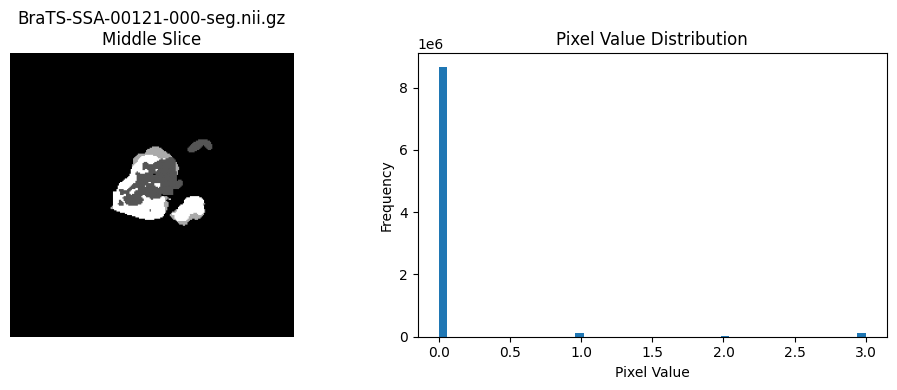


  📁 BraTS-SSA-00206-000-seg.nii.gz
     Shape: (240, 240, 155)
     Unique values: [0. 1. 2. 3.]... (showing first 10)
     Value range: 0.00 - 3.00
     ✅ LIKELY MASK: Only 4 unique values
     🧠 BraTS labels detected: [1, 2, 3]


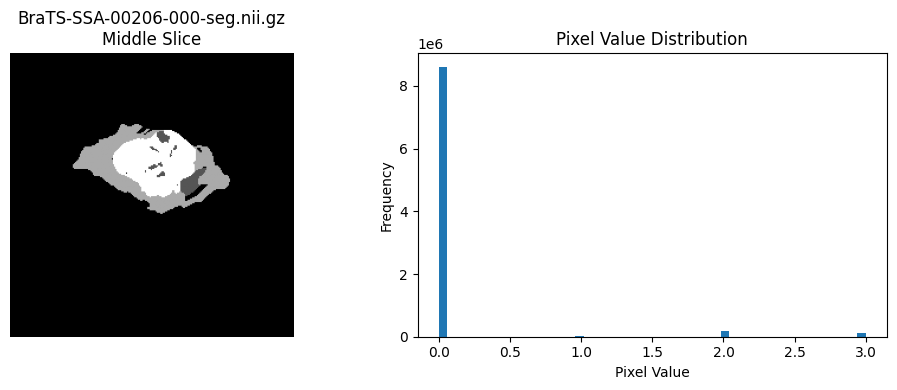


  📁 BraTS-SSA-00050-000-seg.nii.gz
     Shape: (240, 240, 155)
     Unique values: [0. 1. 2. 3.]... (showing first 10)
     Value range: 0.00 - 3.00
     ✅ LIKELY MASK: Only 4 unique values
     🧠 BraTS labels detected: [1, 2, 3]


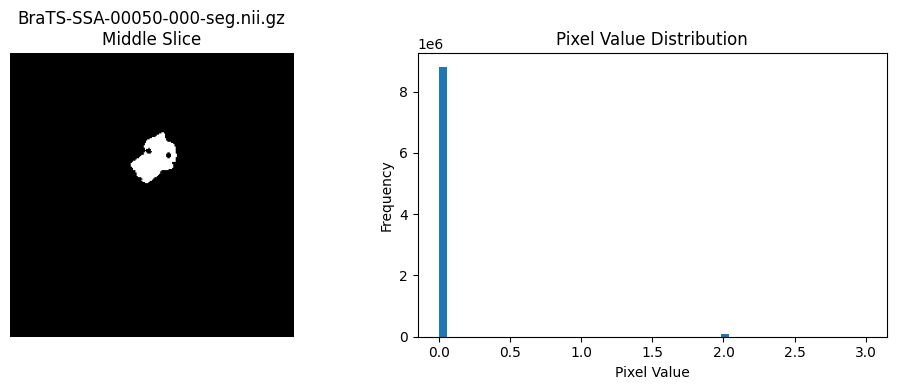


STANDARD BraTS FORMAT CHECK

📋 Checking for standard BraTS file patterns:

  Patient: BraTS-SSA-00121-000
    Found sequences: ['t1', 't2', 'seg']
    ✅ HAS SEGMENTATION MASK!

  Patient: BraTS-SSA-00206-000
    Found sequences: ['t1', 't2', 'seg']
    ✅ HAS SEGMENTATION MASK!

  Patient: BraTS-SSA-00050-000
    Found sequences: ['t1', 't2', 'seg']
    ✅ HAS SEGMENTATION MASK!

  Patient: BraTS-SSA-00164-000
    Found sequences: ['t1', 't2', 'seg']
    ✅ HAS SEGMENTATION MASK!

  Patient: BraTS-SSA-00166-000
    Found sequences: ['t1', 't2', 'seg']
    ✅ HAS SEGMENTATION MASK!

  Patient: BraTS-SSA-00009-000
    Found sequences: ['t1', 't2', 'seg']
    ✅ HAS SEGMENTATION MASK!

FINAL VERDICT

✅ FOUND 20 SEGMENTATION MASK(S) IN THE DATASET!
   You can perform tumor segmentation tasks!

   Available annotations:
     - BraTS-SSA-00121-000-seg.nii.gz
     - BraTS-SSA-00206-000-seg.nii.gz
     - BraTS-SSA-00050-000-seg.nii.gz
     - BraTS-SSA-00223-000-seg.nii.gz
     - BraTS-SSA-00093-00

In [20]:






# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Attention U-Net Training Curves')
plt.legend()
plt.grid(True)
plt.savefig('segmentation_training_curves.png', dpi=150)
plt.show()

# Visualize sample prediction
model.eval()
with torch.no_grad():
    sample_image, sample_mask = next(iter(val_loader))
    sample_image = sample_image.to(device)
    prediction = model(sample_image)
    pred_mask = torch.argmax(prediction, dim=1)

# Display results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
mid_slice = sample_image.shape[3] // 2

axes[0].imshow(sample_image[0, 0, mid_slice].cpu(), cmap='gray')
axes[0].set_title('Input MRI (T1)')
axes[0].axis('off')

axes[1].imshow(sample_mask[0, mid_slice].cpu(), cmap='tab10', vmin=0, vmax=3)
axes[1].set_title('Ground Truth Mask')
axes[1].axis('off')

axes[2].imshow(pred_mask[0, mid_slice].cpu(), cmap='tab10', vmin=0, vmax=3)
axes[2].set_title('Predicted Mask')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('segmentation_results.png', dpi=150)
plt.show()

print("\n=== Training Complete ===")
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Model saved as: best_attention_unet.pth")